In [168]:
import geopandas as gpd
import pandas as pd

data_dir = '/home/andrew/abm_violence/data'
pop_df = pd.read_csv(f"{data_dir}/nhgis0003_csv/nhgis0003_ts_geog2010_cty_sub.csv", skiprows=[1])
gdf = gpd.read_file(f"{data_dir}/nhgis0002_shape/US_cty_sub_2010.shp")

In [175]:
pop_county_lookup = pd.merge(pop_df, gdf, left_on='GISJOIN', right_on='GISJOIN', how='inner', suffixes=('_pop', '_gdf'))
pop_county_lookup = pop_county_lookup[pop_county_lookup['STATE'] != 'Puerto Rico']

In [178]:
pop_county_lookup['CTY_SUBA'].unique(), len(pop_county_lookup)

(array([90171, 90315, 92106, ..., 82650, 88200, 88575], shape=(20352,)), 35613)

In [182]:
pop_county_lookup = pop_county_lookup[['GISJOIN', 'STATE', 'COUNTY',
        'CTY_SUB', 'ALAND10', 'INTPTLAT10',
       'INTPTLON10', 'CL8AA1990', 'CL8AA2000', 'CL8AA2010', 'CL8AA2020']].copy()
pop_county_lookup['INTPTLAT10'] = pd.to_numeric(pop_county_lookup['INTPTLAT10'], errors='coerce')
pop_county_lookup['INTPTLON10'] = pd.to_numeric(pop_county_lookup['INTPTLON10'], errors='coerce')
pop_columns = ['CL8AA1990', 'CL8AA2000', 'CL8AA2010', 'CL8AA2020']
for col in pop_columns:
    pop_county_lookup[col] = pd.to_numeric(pop_county_lookup[col], errors='coerce')
for pop_col in pop_columns:
    pop_county_lookup[pop_col + '_density'] = (pop_county_lookup[pop_col] / (pop_county_lookup['ALAND10'] / 1e6)) 

In [183]:
pop_county_lookup.rename(columns={'INTPTLAT10': 'lat', 'INTPTLON10': 'lng', 
                                  'CL8AA1990': 'population_1990',
                                  'CL8AA2000': 'population_2000',
                                  'CL8AA2010': 'population_2010',
                                  'CL8AA2020': 'population_2020'
                                  }, inplace=True)
pop_county_lookup.to_csv(f"{data_dir}/processed/city_population_density.csv", index=False)

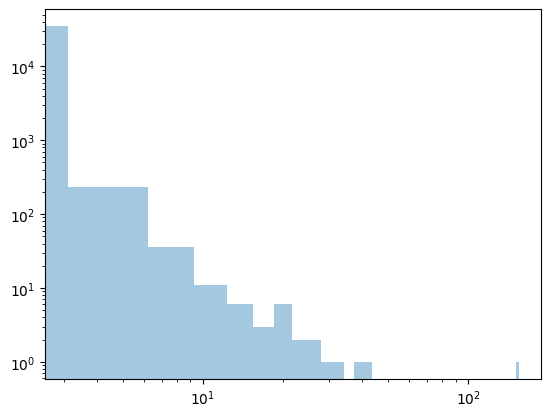

In [ ]:
plt.hist(pop_county_lookup['CL8AA2020_density'] / (pop_county_lookup['CL8AA1990_density'] + 1e1), bins=50, alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.show()